# Assignment 3

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset is a classic dataset used for clustering tasks. It consists of many samples of wine. Here are the key features and characteristics of the dataset:

##### Features (13 chemical properties):
1. Alcohol: The percentage of alcohol in the wine.
2. Malic acid: A type of acid found in grapes, contributing to wine’s tartness.
3. Ash: The total amount of non-volatile substances left after burning the wine
4. Alcalinity of ash: Measures the alkalinity of the ash component of wine.
5. Magnesium: The amount of magnesium in the wine (measured in mg/L).
6. Total phenols: Represents the total amount of phenolic compounds in wine.
7. Flavanoids: A type of phenolic compound responsible for bitterness and astringency.
8. Nonflavanoid phenols: Phenolic compounds that are not flavonoids.
9. Proanthocyanins: A type of tannin that affects astringency and bitterness.
10. Color intensity: Measures the depth or intensity of the wine’s color. 
11. Hue: The shade of color in the wine (ratio of red to yellow tones).
12. OD280/OD315 of diluted wines: Measures the wine’s absorbance at 280 nm and 315 nm, indicating phenol concentration.
13. Proline: An amino acid found in wine, often associated with aging potential and quality.

In [4]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#### **Question 1:** 
#### Data inspection

#### Load the Wine dataset:

Use scikit-learn to load the Wine dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?

In [5]:
from sklearn.datasets import load_wine
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Display the DataFrame
print(wine_df)



     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

In [6]:
#number of rows and columns: 

wine_df.info ()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [7]:
# number of columns = 13; number of rows = 178

In [8]:
# numbers of rows
wine_df.shape[0]

178

In [9]:
#number of columns 
wine_df.shape[1]

13

#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (e.g., alcohol, malic acid, ash...).


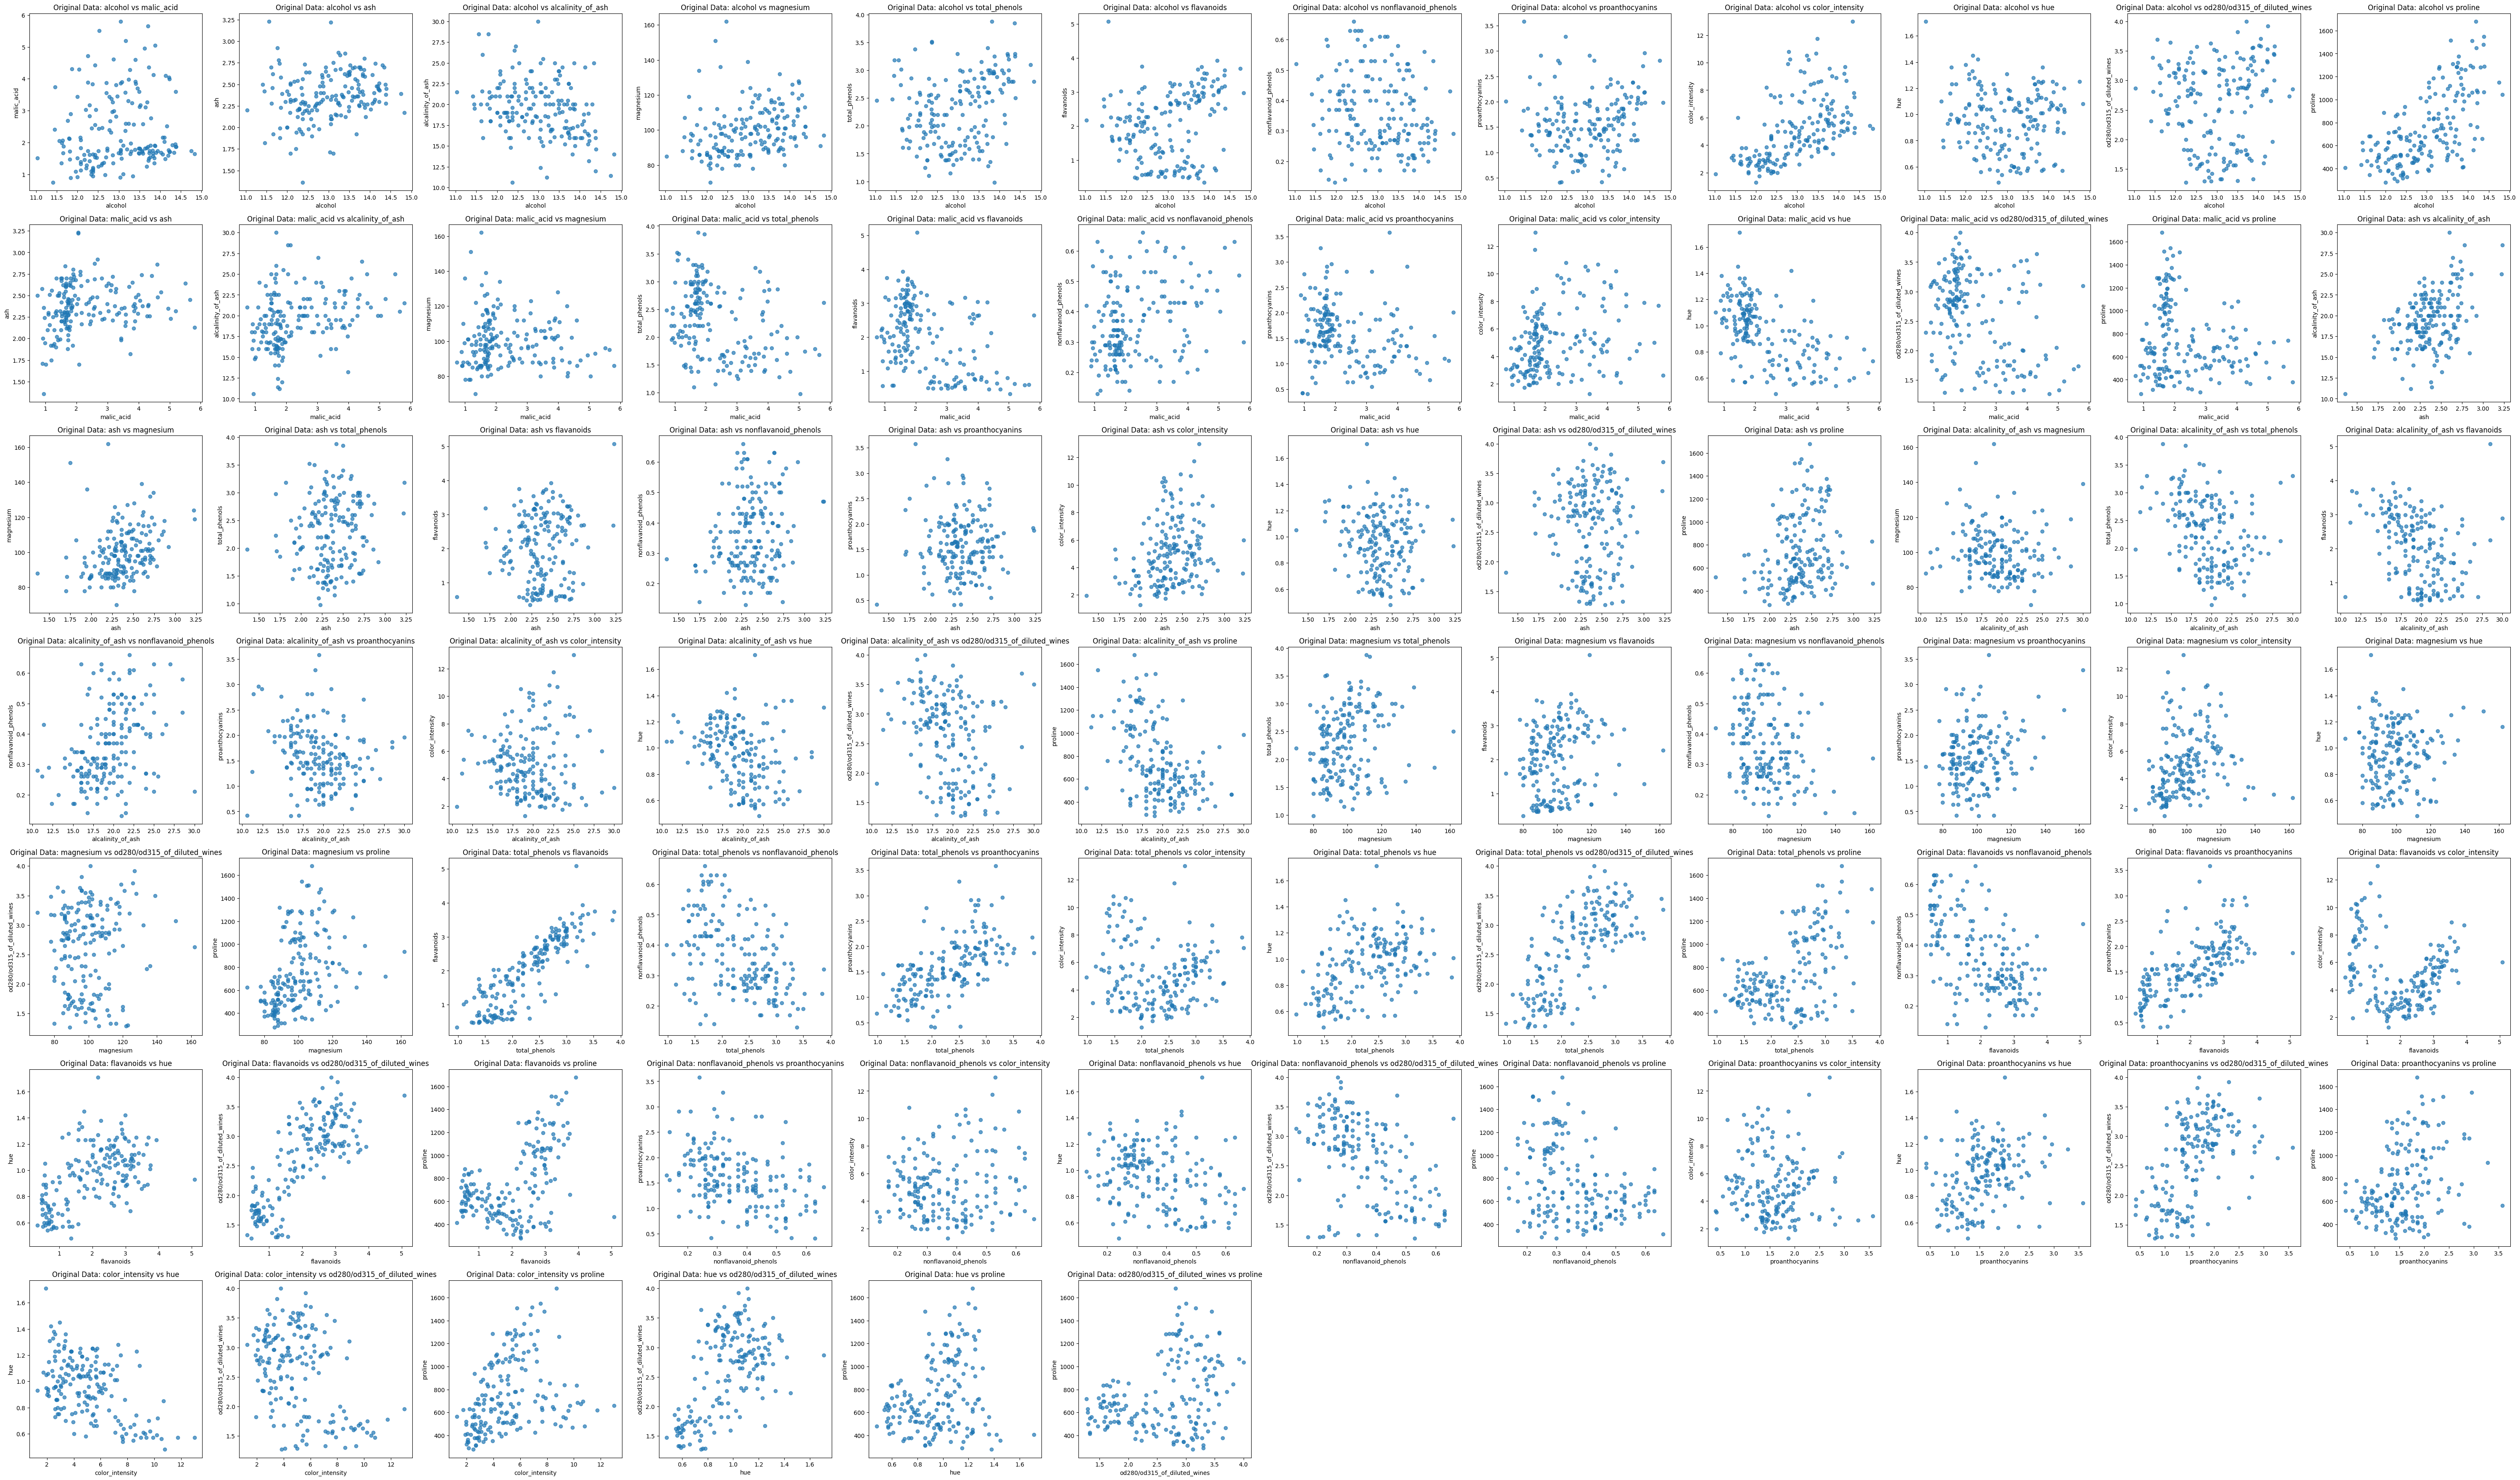

In [10]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = wine_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(wine_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

Yes. For example, in the visualization plotting the data as y=total phenols and x=alcohol, I can identify 3-4 patterns (clusters):
1. low phenol and low alcohol
2. low phenol and high alcohol
3. high alcohol and high phenol
4. and (less "significant") high phenol and low alcohol
A specific combination of phenols and alcohol can help identify/cluster wines by their production method and terroir. For instance, Amarone Valpolicella is characterized by high phenols and high alcohol. 

There are also linear relationships between variables/features that can be identified: 
For exmple, there is a strong positive relationship between total phenols to flavanoids and moderare negative linear association between hue and color intensity [which makes sense sinse hue is red /yellow tones ratio]

#### **Question 3:** 
#### Data cleaning

In [11]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(wine_df)

# Create a new DataFrame with scaled features
scaled_wine_df = pd.DataFrame(scaled_features, columns=wine_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_wine_df.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

In [12]:
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Clustering is based on the measurement of the Euclidean distance between data points and a centroid. Iterative clustering and labelling aim to determine the optimal number of clusters by minimizing the within-cluster sum of squares. For instance, if one feature, such as alcohol content, ranges from 11 to 14.8, while another, such as total scale, ranges from 0.9 to 3.8, this discrepancy can distort distance calculations. In such a case, the alcohol feature may dominate the analysis, potentially altering the grouping process and our interpretation of the data.

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Wine dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

In [13]:
kmeans = KMeans(n_clusters=3, random_state=111, n_init=10)
clusters = kmeans.fit(scaled_wine_df)
clusters.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [14]:
len(clusters.labels_) #verify that all 178 observations are there, groupd into K=3  clusters (0,1,2)

178

In [15]:
# create a new table with the cluster lable as the last column  
clustered_wine_data = scaled_wine_df.copy()  
clustered_wine_data ["Cluster"] = clusters.labels_
clustered_wine_data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Cluster
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,1
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,1
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,1
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,1
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,2
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,2
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575,2
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498,2


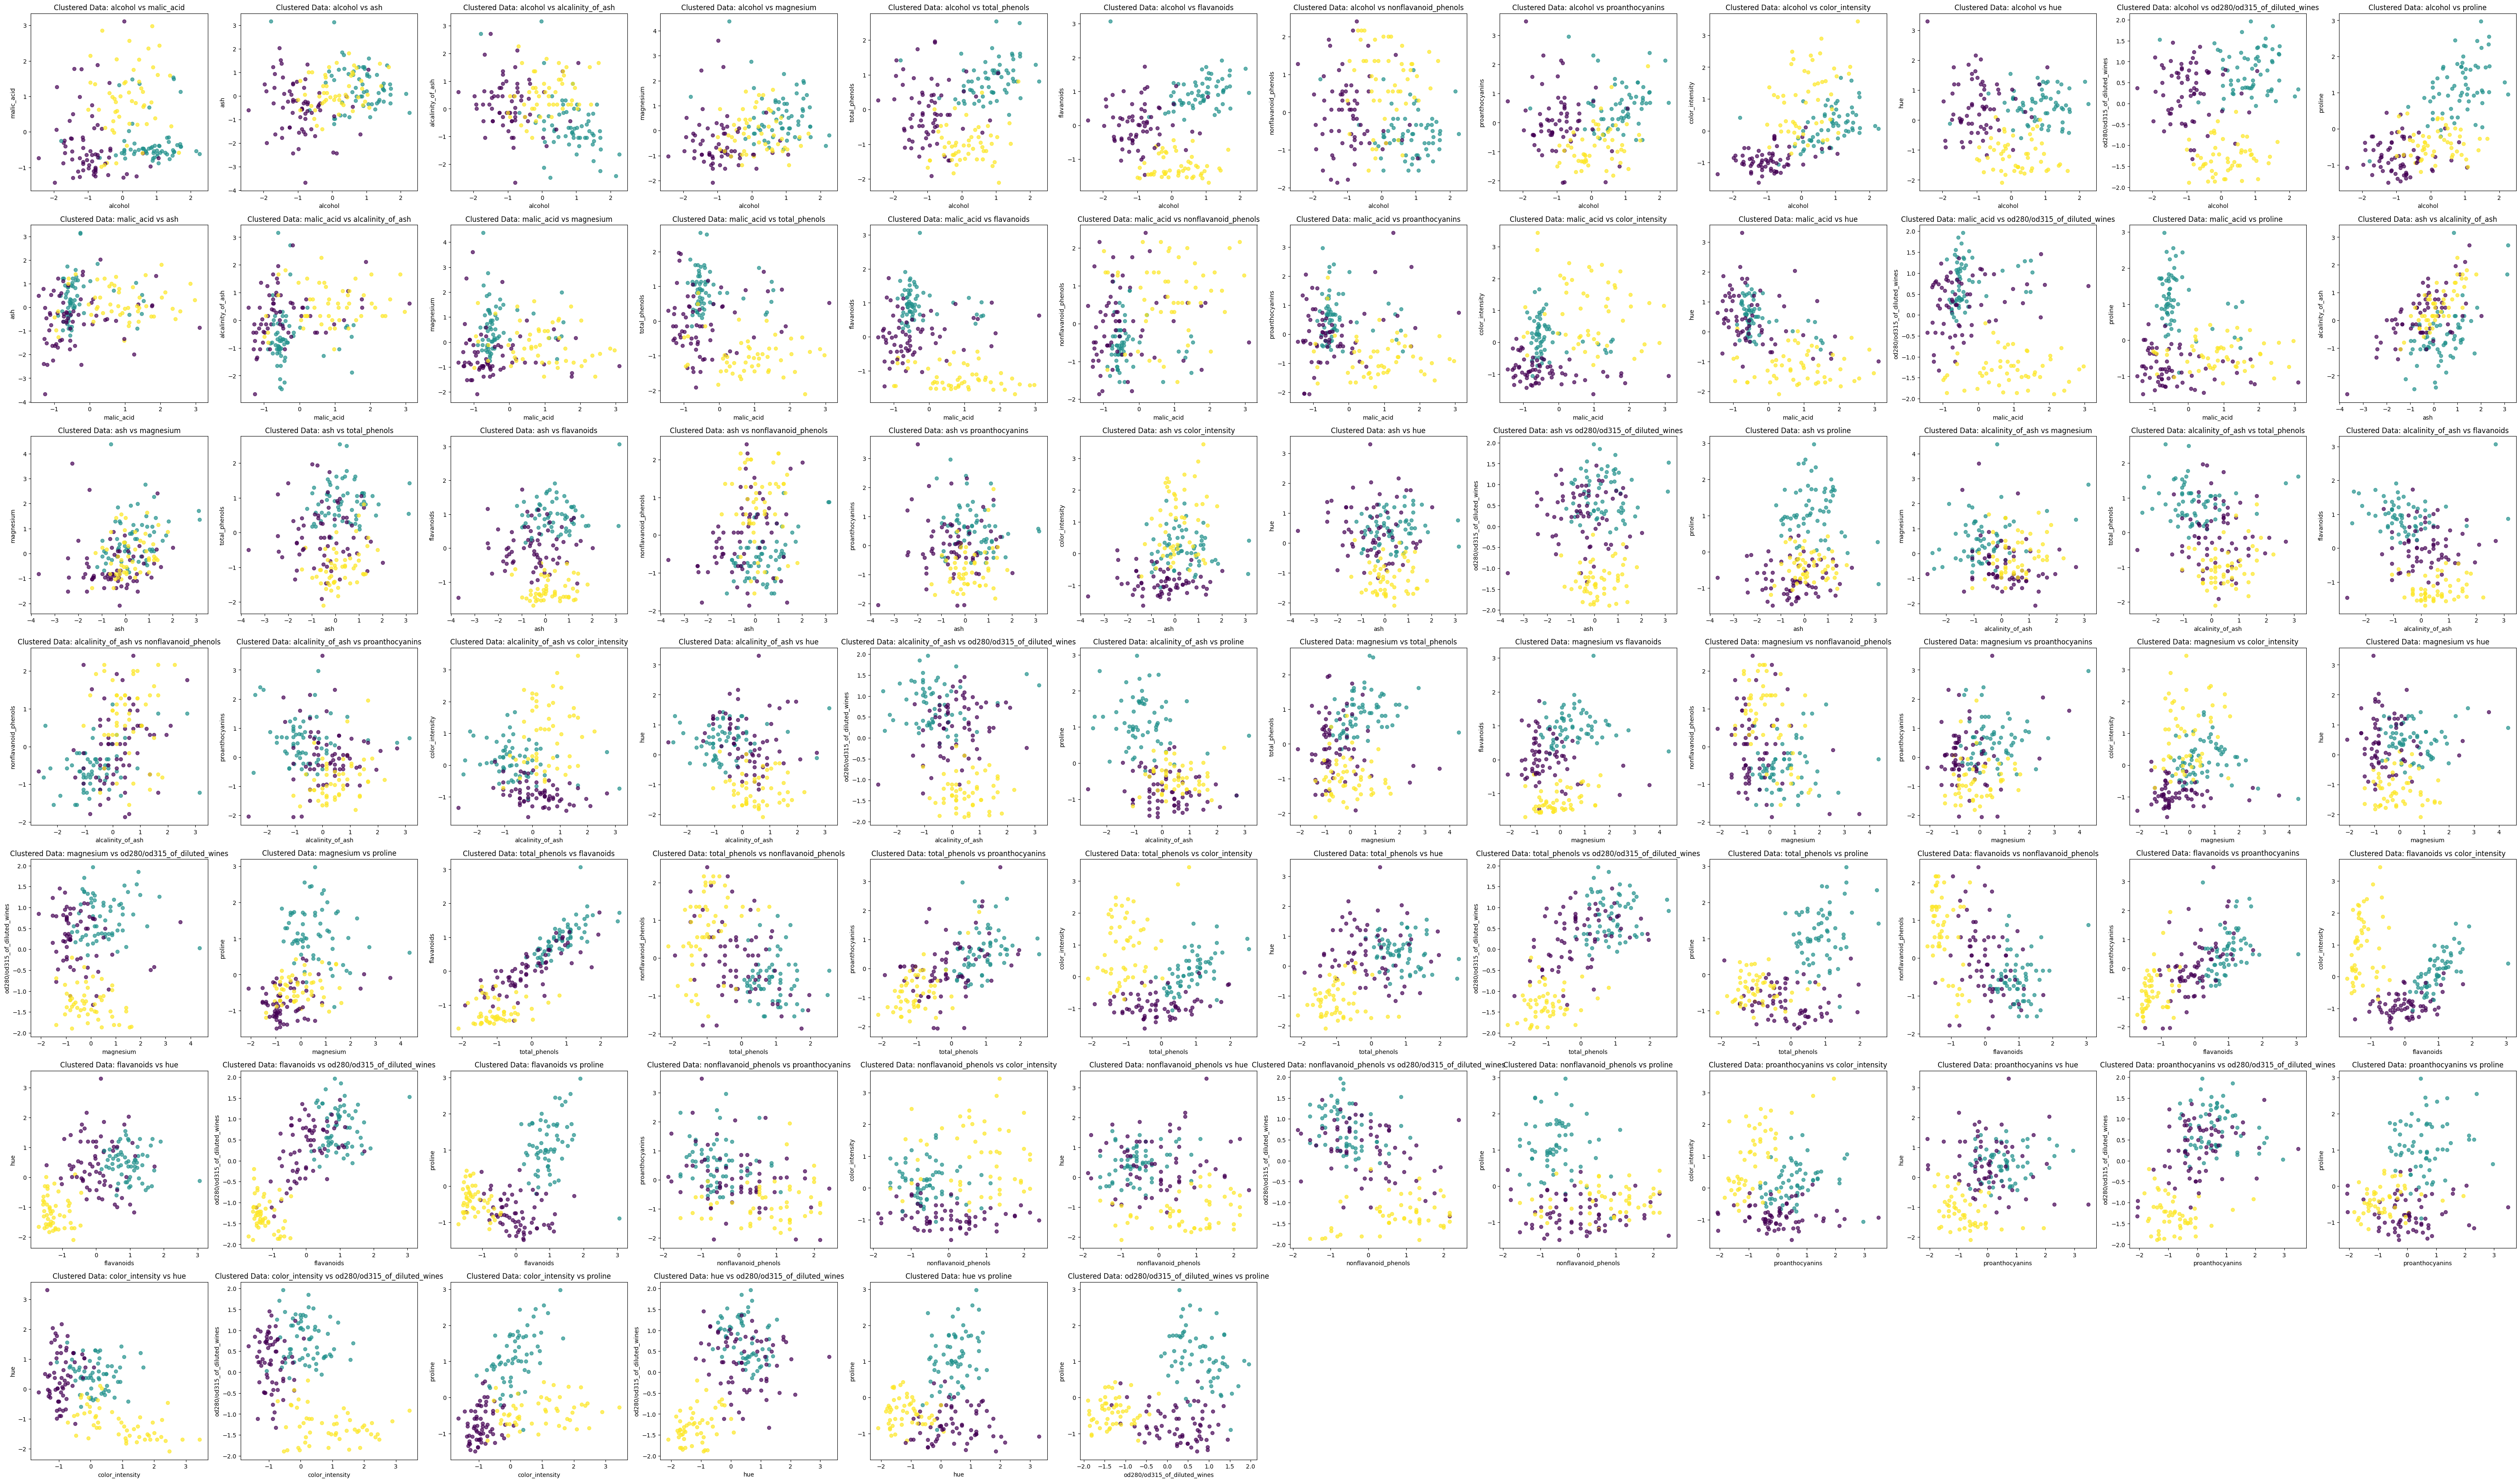

In [16]:

# Use the helper function to plot scatter plots, colored by cluster labels
plot_feature_pairs(clustered_wine_data, feature_names, color_labels=clustered_wine_data["Cluster"], title_prefix='Clustered Data: ')

In [17]:
# I am attempting to find the optimal value of K 
clustered_wine_data_ks = pd.DataFrame(columns=["k", "wssd"])

for k in range(1, 12):
    kmeans = KMeans(n_clusters=k, random_state=111)
    kmeans.fit(scaled_wine_df)
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    clustered_wine_data_ks = pd.concat([clustered_wine_data_ks, current_k], ignore_index=True)

clustered_wine_data_ks

C:\Users\ofirs\AppData\Local\Temp\ipykernel_16796\131205990.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustered_wine_data_ks = pd.concat([clustered_wine_data_ks, current_k], ignore_index=True)


,k,wssd
0,1,2314.000000
1,2,1659.951198
2,3,1277.928489
3,4,1201.638958
4,5,1128.406011
5,6,1063.210841
6,7,1017.338980
7,8,981.830960
8,9,927.322190
9,10,885.208502


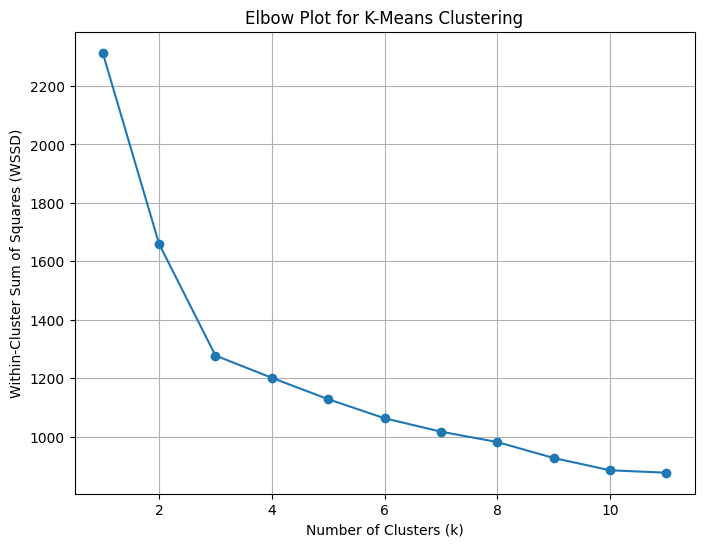

In [18]:
# now I create the plot to find the "elbow"
plt.figure(figsize=(8, 6))
plt.plot(clustered_wine_data_ks['k'], clustered_wine_data_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True)
plt.show()

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

I used the total inertia calculation for each K value between 1 and 11 (total inertia is the sum of WSSDs across all clusters, depending on the number of clusters/centroids). As I added more clusters/centroids, the total inertia decreased. I used the "elbow" method to see where the change in total inertia as a function of K "slows" [i.e., when the slope becomes less steep]. Using this method helps me corroborate the random value of K=3 we determined before and avoid overfitting the data (see the example below, where I use K=178 [number of data points], and the total inertia is equal to 0). 

In [19]:
clustered_wine_data_ks = pd.DataFrame(columns=["k", "wssd"])

for k in range(1, 179, 1):
    kmeans = KMeans(n_clusters=k, random_state=111)
    kmeans.fit(scaled_wine_df)
    current_k = pd.DataFrame({"k": [k], "wssd": [kmeans.inertia_]})
    clustered_wine_data_ks = pd.concat([clustered_wine_data_ks, current_k], ignore_index=True)

clustered_wine_data_ks

C:\Users\ofirs\AppData\Local\Temp\ipykernel_16796\1447663212.py:7: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  clustered_wine_data_ks = pd.concat([clustered_wine_data_ks, current_k], ignore_index=True)


,k,wssd
0,1,2314.000000
1,2,1659.951198
2,3,1277.928489
3,4,1201.638958
4,5,1128.406011
...,...,...
173,174,2.953175
174,175,2.118809
175,176,1.387538
176,177,0.677580


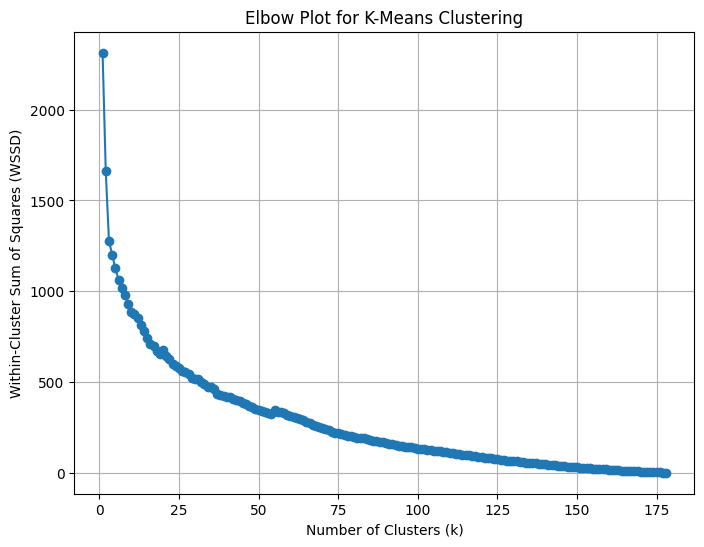

In [20]:
# now I create the plot to find the "elbow"
plt.figure(figsize=(8, 6))
plt.plot(clustered_wine_data_ks['k'], clustered_wine_data_ks['wssd'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSSD)')
plt.title('Elbow Plot for K-Means Clustering')
plt.grid(True)
plt.show()

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of `color intensity`. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

In [21]:
wine_df["color_intensity"].mean()
#check the mean in our sample as a first stage. Then I will use bootstrapping to estimate the "real" parameter using bootstrapping and confidence interval

np.float64(5.058089882022472)

In [22]:
# I will use all the data which is available to me (n=178) and verify the mean
np.random.seed(123)
my_sample = wine_df.sample(n=178)
my_sample['color_intensity'].mean()

np.float64(5.058089882022472)

In [23]:
#for examplification, I will create onebottstrap sample to verify that mean value changes 
boot1 = my_sample.sample(frac=1, replace=True)
boot1['color_intensity'].mean()

np.float64(4.954550556179775)

In [24]:
# I will generate 10_000 bootstrap samples
bootstrap_samples = []

for i in range(10_000):
    sample = my_sample.sample(frac=1, replace=True)  
    sample = sample.assign(replicate=i) 
    bootstrap_samples.append(sample)  

boot10_000 = pd.concat(bootstrap_samples)

boot10_000

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,replicate
158,14.34,1.68,2.70,25.0,98.0,2.80,1.31,0.53,2.70,13.00,0.570,1.96,660.0,0
150,13.50,3.12,2.62,24.0,123.0,1.40,1.57,0.22,1.25,8.60,0.590,1.30,500.0,0
172,14.16,2.51,2.48,20.0,91.0,1.68,0.70,0.44,1.24,9.70,0.620,1.71,660.0,0
103,11.82,1.72,1.88,19.5,86.0,2.50,1.64,0.37,1.42,2.06,0.940,2.44,415.0,0
134,12.51,1.24,2.25,17.5,85.0,2.00,0.58,0.60,1.25,5.45,0.750,1.51,650.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,13.62,4.95,2.35,20.0,92.0,2.00,0.80,0.47,1.02,4.40,0.910,2.05,550.0,9999
138,13.49,3.59,2.19,19.5,88.0,1.62,0.48,0.58,0.88,5.70,0.810,1.82,580.0,9999
70,12.29,1.61,2.21,20.4,103.0,1.10,1.02,0.37,1.46,3.05,0.906,1.82,870.0,9999
133,12.70,3.55,2.36,21.5,106.0,1.70,1.20,0.17,0.84,5.00,0.780,1.29,600.0,9999


In [25]:
# I will chart/create the distribution of bootstap samples means of color_intensity 
boot_means = boot10_000.groupby('replicate')['color_intensity'].mean().reset_index(name='mean_color_intensity')
boot_means

,replicate,mean_color_intensity
0,0,5.195393
1,1,5.310000
2,2,5.030618
3,3,4.925449
4,4,5.183315
...,...,...
9995,9995,5.048090
9996,9996,4.876011
9997,9997,5.113090
9998,9998,5.245787


In [26]:
#I will calcualte the mean of bootstrap sample  means
mean_color_intensity = boot_means["mean_color_intensity"].mean()
mean_color_intensity

np.float64(5.059890820270225)

In [27]:
# I will compare it now with the original (calcualte the gap)
mean_color_intensity - wine_df["color_intensity"].mean() 

np.float64(0.001800938247753514)

In [28]:
# I will calculate lower bound for 90% confidence intervals

lower_bound = boot_means["mean_color_intensity"].quantile([0.05])
lower_bound

0.05    4.777975
Name: mean_color_intensity, dtype: float64

In [29]:
# I will calculate upper bound for 90% confidence intervals

upper_bound = boot_means["mean_color_intensity"].quantile([0.95])
upper_bound

0.95    5.345486
Name: mean_color_intensity, dtype: float64

In [30]:
# I will Display the result
print(f"Mean of Color Intensity: {mean_color_intensity}")
print(f"90% Confidence Interval of Mean Color Intensity: ({lower_bound}, {upper_bound})")

Mean of Color Intensity: 5.059890820270225
90% Confidence Interval of Mean Color Intensity: (0.05    4.777975
Name: mean_color_intensity, dtype: float64, 0.95    5.345486
Name: mean_color_intensity, dtype: float64)


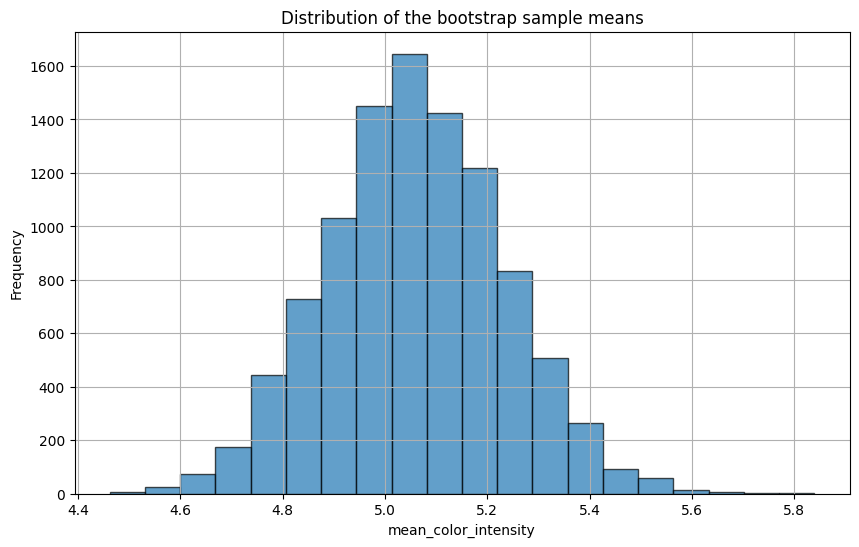

In [32]:
# I will Plot the histogram of the bootstrap distribution to see its shape and  be able to lean more about color  intensity feature
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(boot_means['mean_color_intensity'], bins=20, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Distribution of the bootstrap sample means')
plt.xlabel('mean_color_intensity')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?

To answer this question, let's assume that the data set of N=178 wine samples available to me (thanks to the sklearn datasets effort) is just a subset of a larger data set held by the LCBO, which includes all wine samples collected in Ontario since 1984. If I want to estimate the mean for wine colour intensity in Ontario since 1984 (i.e., the population parameter [which is only known to the CEO of the LCBO]), I will need to simulate a sample distribution generated by taking 10,000 samples of 178 wine samples from the LCBO's repository. Even if the LCBO's CEO provided me or allowed sklearn datasets access to this "Ontario wine samples population," it would take an impractical amount of time to sample 10,000 sets of 178. Instead, I created 10,000 bootstrap samples with replacement to mimic the process of generating a sampling distribution. Doing so, I managed to calcualte the mean of the bootstrap sampaling distibution and estimate the population parameter based on the data available to me 

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

Calculating the 90% confidence interval from the bootstrap sampling distribution simulates the sampling distribution. As a result, I can estimate with 90% confidence that the true population mean for wine colour intensity (in the LCBO exclusive repository) lies between 4.777 and 5.345.

**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the color intensity appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

In [34]:
se_mean_color_intensity = boot_means["mean_color_intensity"].sem()
se_mean_color_intensity

np.float64(0.0017289599120930916)

Reflecting on the bootstrap sampling distribution, which shows a perfect bell-shaped/normal distribution (compared to the skewed distribution of ARBNB prices in Vancouver). The symmetry of the upper and lower bounds of the confidence interval values, along with the small standard error of the mean, indicates that the mean colour intensity is a stable and reliable estimate. In other words, the sample of N=178, drawn by sklearn from the LCBO provincial wine samples repository, accurately represents the latter mean of wine color intensity.

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are correctly interpreted to explore relationships between features and species. | Visualizations are not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 12/10/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc2-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
